# Diabetes — Modelos de Regresión

Análisis exploratorio, preprocesamiento, entrenamiento y evaluación de:
- **Regresión Lineal Múltiple**
- **Regresión Polinomial** (grados 2 y 3)

**Variable objetivo:** `Y` (progresión cuantitativa de la diabetes un año después del inicio).

## 1. Configuración del entorno

Se importan las librerías y los módulos del caso. Se agrega la raíz del proyecto al `sys.path` para poder importar `cases`.

In [1]:
import sys
from pathlib import Path

# Permite importar el paquete cases/ desde el notebook.
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from cases.diabetes.config import (
    RESULTS_DIR, RANDOM_STATE, TEST_SIZE, TARGET, NUMERIC_FEATURES,
)
from cases.diabetes.preprocessing import load_data, build_preprocessor
from cases.diabetes.train import build_models
from cases.diabetes.evaluate import metrics_table

print('Entorno listo. Python', sys.version.split()[0])

Entorno listo. Python 3.14.6


## 2. Carga de diabetes.tab.txt

El dataset **no es un CSV con coma**: es un archivo de texto separado por **tabulaciones** (`.tab.txt`). Se lee con `sep='\t'`. El encabezado es la primera línea: `AGE SEX BMI BP S1 S2 S3 S4 S5 S6 Y`.

In [2]:
df = load_data()
print('Dimensiones (filas, columnas):', df.shape)
print('Columnas:', list(df.columns))
df.head()

Dimensiones (filas, columnas): (442, 11)
Columnas: ['AGE', 'SEX', 'BMI', 'BP', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'Y']


,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135


## 3. Información general y tipos de datos

Todas las variables son numéricas. `SEX` toma valores 1 o 2 y se trata como variable numérica binaria; no hay variables categóricas con nombres.

In [3]:
df.info()
print()
print('Tipos de datos:')
print(df.dtypes.to_string())

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AGE     442 non-null    int64  
 1   SEX     442 non-null    int64  
 2   BMI     442 non-null    float64
 3   BP      442 non-null    float64
 4   S1      442 non-null    int64  
 5   S2      442 non-null    float64
 6   S3      442 non-null    float64
 7   S4      442 non-null    float64
 8   S5      442 non-null    float64
 9   S6      442 non-null    int64  
 10  Y       442 non-null    int64  
dtypes: float64(6), int64(5)
memory usage: 38.1 KB

Tipos de datos:
AGE      int64
SEX      int64
BMI    float64
BP     float64
S1       int64
S2     float64
S3     float64
S4     float64
S5     float64
S6       int64
Y        int64


## 4. Valores nulos

El dataset no presenta valores faltantes en ninguna columna.

In [4]:
nulos = df.isna().sum()
porcentaje = (df.isna().mean() * 100).round(3)
pd.DataFrame({'Nulos': nulos, 'Porcentaje %': porcentaje})

,Nulos,Porcentaje %
AGE,0,0.0
SEX,0,0.0
BMI,0,0.0
BP,0,0.0
S1,0,0.0
S2,0,0.0
S3,0,0.0
S4,0,0.0
S5,0,0.0
S6,0,0.0


## 5. Duplicados

Se verifica la existencia de filas duplicadas.

In [5]:
print('Filas duplicadas:', df.duplicated().sum())

Filas duplicadas: 0


## 6. Estadísticas descriptivas

Resumen de las variables basales y del objetivo. `Y` va de 25 a 346 con media 152.1; las escalas de las variables son muy distintas, lo que justifica la estandarización.

In [6]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
AGE,442.0,48.52,13.11,19.00,38.25,50.00,59.00,79.00
SEX,442.0,1.47,0.50,1.00,1.00,1.00,2.00,2.00
BMI,442.0,26.38,4.42,18.00,23.20,25.70,29.28,42.20
BP,442.0,94.65,13.83,62.00,84.00,93.00,105.00,133.00
S1,442.0,189.14,34.61,97.00,164.25,186.00,209.75,301.00
S2,442.0,115.44,30.41,41.60,96.05,113.00,134.50,242.40
S3,442.0,49.79,12.93,22.00,40.25,48.00,57.75,99.00
S4,442.0,4.07,1.29,2.00,3.00,4.00,5.00,9.09
S5,442.0,4.64,0.52,3.26,4.28,4.62,5.00,6.11
S6,442.0,91.26,11.50,58.00,83.25,91.00,98.00,124.00


## 7. Variable objetivo: Y

`Y` es la **progresión cuantitativa de la diabetes un año después del inicio**. Es una variable continua de regresión.

Estadísticos de Y:
count    442.00
mean     152.13
std       77.09
min       25.00
25%       87.00
50%      140.50
75%      211.50
max      346.00


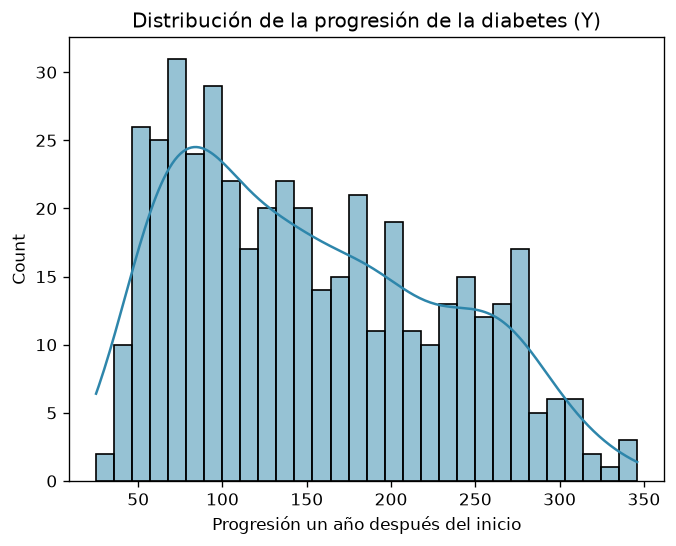

In [7]:
print('Estadísticos de Y:')
print(df['Y'].describe().round(2).to_string())

sns.histplot(df['Y'], bins=30, kde=True, color='#2E86AB')
plt.title('Distribución de la progresión de la diabetes (Y)')
plt.xlabel('Progresión un año después del inicio')
plt.show()

## 8. Distribuciones de las variables basales

Histogramas de los 10 descriptores. La mayoría presenta una forma aproximadamente normal o ligeramente asimétrica.

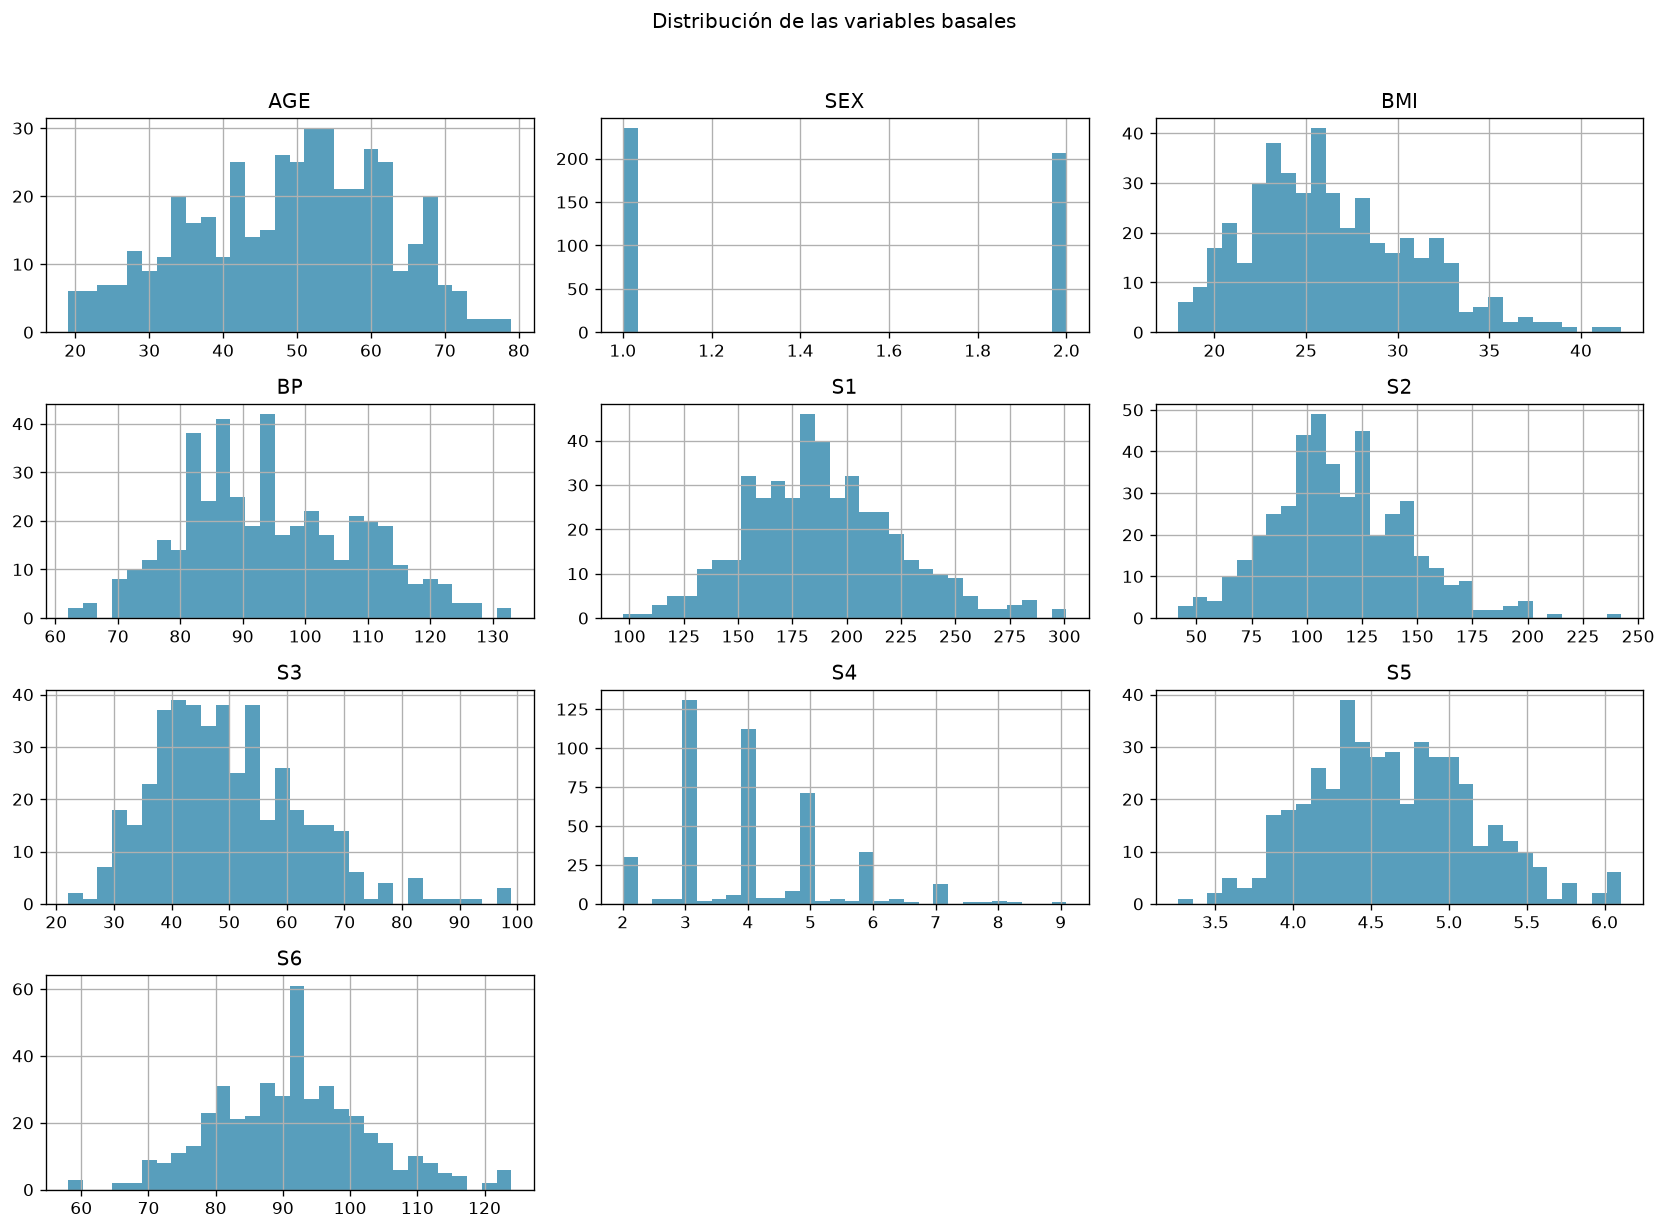

In [8]:
df[NUMERIC_FEATURES].hist(bins=30, figsize=(14, 10), color='#2E86AB', alpha=0.8)
plt.suptitle('Distribución de las variables basales', y=1.02)
plt.tight_layout()
plt.show()

## 9. Análisis de outliers

Se usan boxplots y la regla del IQR. Los valores extremos son escasos (≤2%) y corresponden a pacientes reales con valores altos; **se conservan** como observaciones válidas.

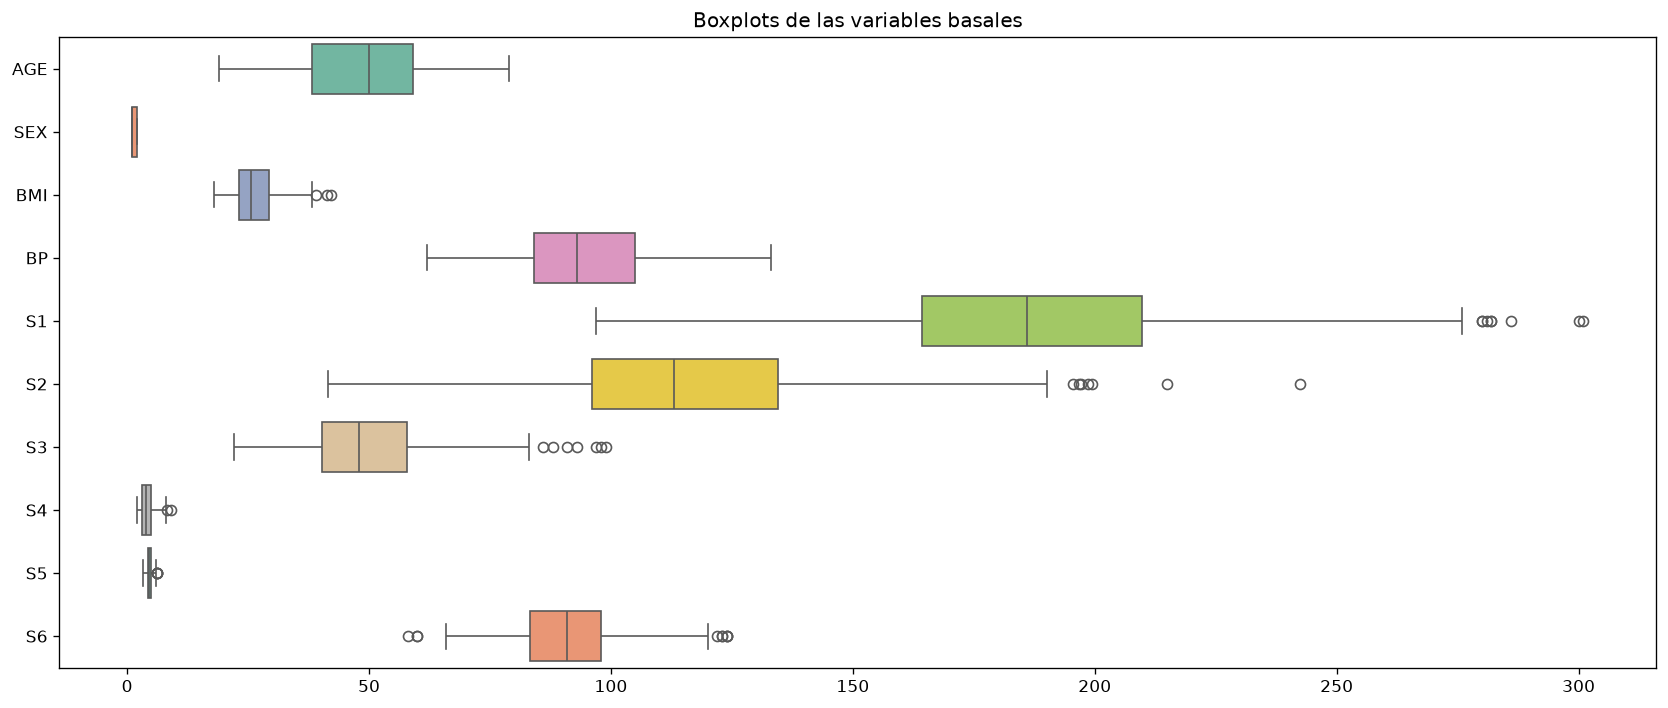

In [9]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[NUMERIC_FEATURES], orient='h', palette='Set2')
plt.title('Boxplots de las variables basales')
plt.tight_layout()
plt.show()

In [10]:
print('Outliers por IQR:')
print(f"{'Variable':<4s} {'Outliers':>8s} {'%':>8s}")
for col in NUMERIC_FEATURES:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    mask = (df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)
    print(f"{col:<4s} {int(mask.sum()):>8d} {100 * mask.mean():>7.2f}%")

Outliers por IQR:
Variable Outliers        %
AGE         0    0.00%
SEX         0    0.00%
BMI         3    0.68%
BP          0    0.00%
S1          8    1.81%
S2          7    1.58%
S3          7    1.58%
S4          2    0.45%
S5          4    0.90%
S6          9    2.04%


## 10. Matriz de correlación

Se muestra la correlación de Pearson. Los predictores más relacionados con `Y` son `BMI` (0.59) y `S5` (0.57); `S3` correlaciona negativamente (−0.40). Hay correlaciones altas entre las medidas séricas S1-S6.

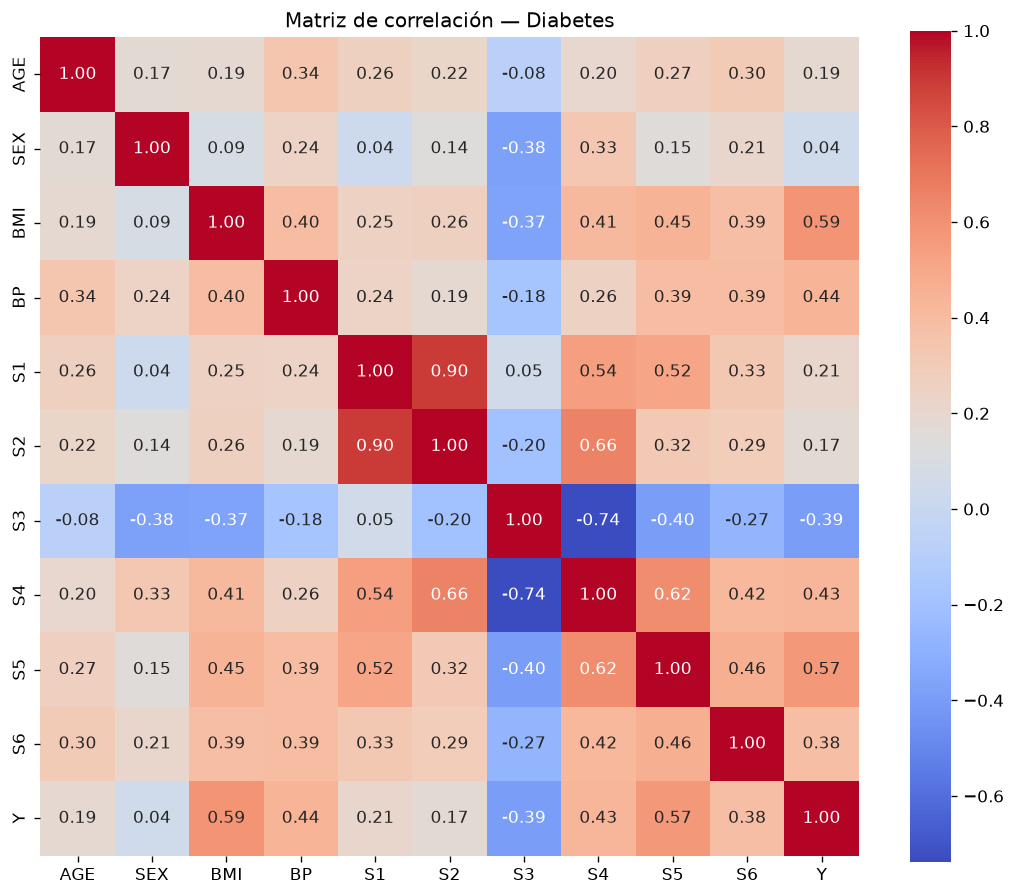

In [11]:
corr = df[NUMERIC_FEATURES + [TARGET]].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matriz de correlación — Diabetes')
plt.show()

In [12]:
print('Correlación con la variable objetivo:')
print(corr[TARGET].sort_values(ascending=False).round(3).to_string())

Correlación con la variable objetivo:
Y      1.000
BMI    0.586
S5     0.566
BP     0.441
S4     0.430
S6     0.382
S1     0.212
AGE    0.188
S2     0.174
SEX    0.043
S3    -0.395


## 11. Multicolinealidad (VIF)

El VIF cuantifica la inflación de la varianza de cada coeficiente. Valores > 10 indican multicolinealidad severa. Aquí las medidas séricas S1-S6 están muy correlacionadas entre sí: `S1` VIF=577, `S5` VIF=277, `S2` VIF=245.

Consecuencia: los coeficientes individuales son poco estables. Sin embargo, la predicción global es válida y **no se eliminan variables**.

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[NUMERIC_FEATURES].astype(float)
vif_table = []
for i in range(X_vif.shape[1]):
    vif = variance_inflation_factor(X_vif.to_numpy(), i)
    vif_table.append((X_vif.columns[i], round(vif, 2)))
pd.DataFrame(vif_table, columns=['Variable', 'VIF'])

,Variable,VIF
0,AGE,17.88
1,SEX,12.19
2,BMI,55.16
3,BP,69.40
4,S1,576.89
5,S2,244.91
6,S3,52.29
7,S4,81.35
8,S5,277.18
9,S6,93.98


## 12. Preprocesamiento

Se construye un `ColumnTransformer` numérico: imputación con mediana (no hay nulos; por robustez) + `StandardScaler`. Los transformadores se ajustan solo con el conjunto de entrenamiento para evitar data leakage.

In [14]:
preprocessor = build_preprocessor()
print('Preprocesador creado.')
preprocessor

Preprocesador creado.


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{fe

## 13. División Train/Test

80% entrenamiento / 20% prueba con `random_state=42`.

In [15]:
X = df.drop(columns=[TARGET])
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas')

Train: 353 filas | Test: 89 filas


## 14. Modelos y pipelines

Se entrenan los tres pipelines: Regresión Lineal Múltiple y Regresión Polinomial de grados 2 y 3 (66 y 286 características respectivamente).

In [16]:
models = build_models(preprocessor)
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    print(f'Entrenado: {name}')

Entrenado: linear_regression
Entrenado: polynomial_degree_2
Entrenado: polynomial_degree_3


## 15. Evaluación

Métricas en prueba: MAE, MSE, RMSE y R².

In [17]:
table = metrics_table(models, X_train, y_train, X_test, y_test)
table.round(2)

,Modelo,R2_train,RMSE_train,R2_test,RMSE_test,MAE_test,MSE_test
0,linear_regression,0.53,53.56,0.45,53.85,42.79,2900.19
1,polynomial_degree_2,0.61,48.92,0.42,55.64,43.58,3096.03
2,polynomial_degree_3,0.88,27.38,-14.28,284.57,162.32,80980.76


## 16. Análisis de sobreajuste

Se comparan R² y RMSE de entrenamiento frente a prueba. Una gran brecha indica sobreajuste: el modelo memoriza el entrenamiento pero no generaliza.

In [18]:
over = table[['Modelo', 'R2_train', 'R2_test', 'RMSE_train', 'RMSE_test']]
over.round(2)

,Modelo,R2_train,R2_test,RMSE_train,RMSE_test
0,linear_regression,0.53,0.45,53.56,53.85
1,polynomial_degree_2,0.61,0.42,48.92,55.64
2,polynomial_degree_3,0.88,-14.28,27.38,284.57


## 17. Selección del mejor modelo

El **modelo lineal** obtiene el mejor R² en prueba (0.45). El grado 3 **sobreajusta** severamente: R² de entrenamiento 0.88 pero R² en prueba de −14.28.

In [19]:
best = table.loc[table['R2_test'].idxmax(), 'Modelo']
print('Mejor modelo (R² test):', best)
table.nlargest(1, 'R2_test').round(2)

Mejor modelo (R² test): linear_regression


,Modelo,R2_train,RMSE_train,R2_test,RMSE_test,MAE_test,MSE_test
0,linear_regression,0.53,53.56,0.45,53.85,42.79,2900.19


## 18. Visualizaciones

Gráficos reales vs predichos y residuos del mejor modelo (lineal).

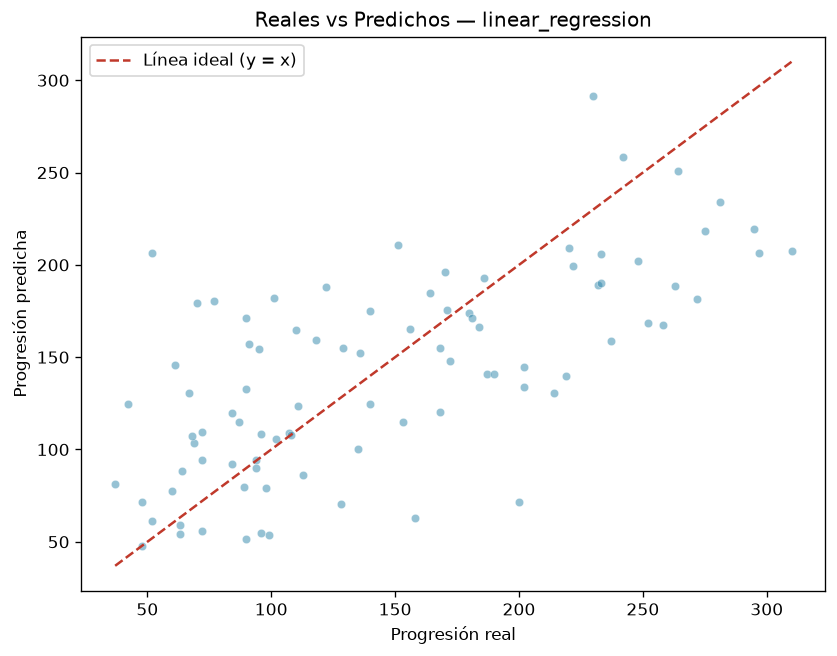

In [20]:
best_model = models[best]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.5, s=25, color='#2E86AB')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
plt.plot(lims, lims, '--', color='#C0392B', label='Línea ideal (y = x)')
plt.xlabel('Progresión real'); plt.ylabel('Progresión predicha')
plt.title(f'Reales vs Predichos — {best}')
plt.legend(); plt.show()

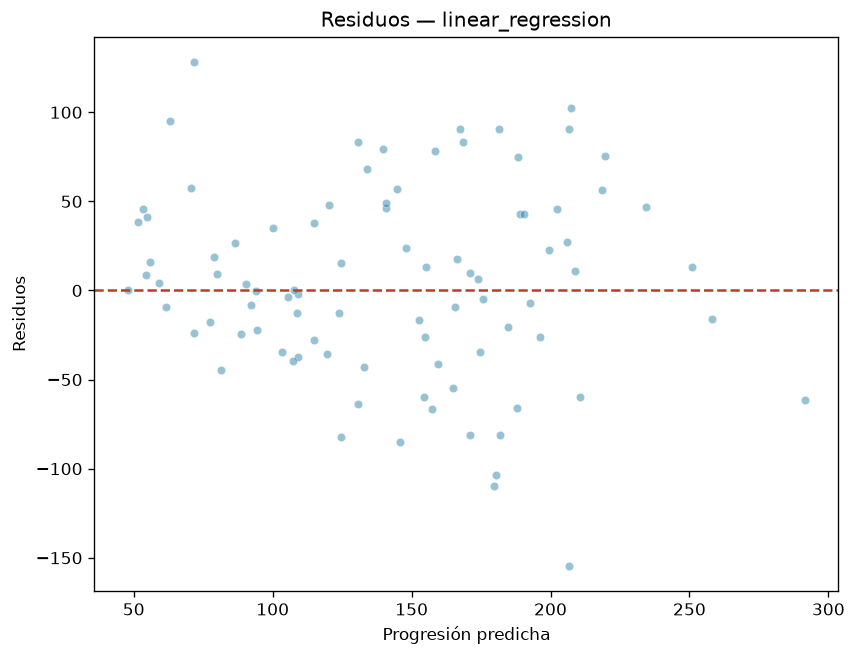

In [21]:
residuals = y_test - y_pred_best
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_best, y=residuals, alpha=0.5, s=25, color='#2E86AB')
plt.axhline(0, color='#C0392B', linestyle='--')
plt.xlabel('Progresión predicha'); plt.ylabel('Residuos')
plt.title(f'Residuos — {best}')
plt.show()

## 19. Guardado de modelos

Los pipelines se guardan con `joblib` en `models/diabetes/`; la aplicación Streamlit los carga sin reentrenarlos.

In [22]:
import joblib
from cases.diabetes.config import MODELS_DIR

for name, pipeline in models.items():
    joblib.dump(pipeline, MODELS_DIR / f'{name}.pkl')
print('Modelos guardados en:', MODELS_DIR)

Modelos guardados en: C:\Users\alexl\OneDrive\Desktop\IA\Unidad1\Proyecto03\models\diabetes


## 20. Predicción de ejemplo

Se predice la progresión de un paciente típico (medianas de cada variable).

In [23]:
from cases.diabetes.predict import predict

sample = {'AGE': 50, 'SEX': 1, 'BMI': 25.7, 'BP': 93.0, 'S1': 186.0,
          'S2': 113.0, 'S3': 48.0, 'S4': 4.0, 'S5': 4.62, 'S6': 91.0}

for key in models:
    print(f'{key:22s} -> {predict(key, sample):.2f}')

linear_regression      -> 155.20
polynomial_degree_2    -> 36.71
polynomial_degree_3    -> -7458.74


## 21. Conclusiones

- El dataset `diabetes.tab.txt` (tabulado) tiene 442 registros, sin nulos ni duplicados.
- `BMI` y `S5` son los predictores más correlacionados con la progresión.
- La multicolinealidad entre S1-S6 es severa (VIF > 200); se documenta y no se eliminan variables.
- El **modelo lineal es el mejor** (R² test 0.45); el grado 3 **sobreajusta** (R² test −14.28).
- El proyecto es académico y predictivo: las predicciones no constituyen un diagnóstico médico.